In [1]:
import os
from pathlib import Path

USE_KAGGLE_DOWNLOAD = True
LOCAL_DATASET_ROOT = None  # Example: "/Users/you/Downloads/food-101/food-101"

if LOCAL_DATASET_ROOT is not None:
    base_path = Path(LOCAL_DATASET_ROOT).expanduser().resolve()
else:
    if not USE_KAGGLE_DOWNLOAD:
        raise ValueError("Set LOCAL_DATASET_ROOT or enable USE_KAGGLE_DOWNLOAD.")

    import kagglehub
    path = kagglehub.dataset_download("dansbecker/food-101")
    base_path = Path(path) / "food-101" / "food-101"

print("Using dataset:", base_path)

Using dataset: /Users/jordankaseram/.cache/kagglehub/datasets/dansbecker/food-101/versions/1/food-101/food-101


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

results_df = pd.read_csv("efficientnetv2_results_try2.csv")
results_df


,strategy,clean_test_acc,clean_test_loss,trainable_params,train_seconds,best_val_acc,variant_blur_little_acc,variant_blur_little_loss,variant_blur_medium_acc,variant_blur_medium_loss,variant_clean_acc,variant_clean_loss,variant_downsampled_acc,variant_downsampled_loss,variant_masked_acc,variant_masked_loss,variant_noise_rotation_acc,variant_noise_rotation_loss
0,batchnorm_tuning,0.862099,0.481698,283253,4542.646356,0.823168,0.778733,0.808341,0.593901,1.608468,0.854020,0.512370,0.273941,3.730265,0.848000,0.534148,0.806931,0.690686
1,lora_tuning,0.841386,0.556213,902153,3812.468396,0.801716,0.747406,0.910311,0.555960,1.753219,0.829584,0.601226,0.262020,3.437535,0.820832,0.631296,0.768673,0.825799
2,adapter_tuning,0.761743,0.850954,348901,1768.577542,0.748251,0.637069,1.352443,0.407604,2.379842,0.749624,0.895768,0.164198,4.037191,0.741069,0.931231,0.682693,1.151849
3,linear_probe,0.646772,1.324890,129381,5473.958655,0.602310,0.483168,2.081947,0.279089,3.104169,0.633347,1.394375,0.087168,4.917770,0.622297,1.440070,0.564911,1.697061


In [3]:
# Cell 1: load metrics from CSV + JSON
from pathlib import Path
import json
import pandas as pd

PROJECT_DIR = Path("/Users/jordankaseram/Documents/UBC/Data 586/Food-101/EfficentNetV2")

results_df = pd.read_csv(PROJECT_DIR / "efficientnetv2_results_try2.csv")

history_files = {
    "linear_probe": PROJECT_DIR / "history_linear_efficientnetv2.json",
    "batchnorm_tuning": PROJECT_DIR / "history_bn_efficientnetv2.json",
    "adapter_tuning": PROJECT_DIR / "history_adapter_efficientnetv2.json",
    "lora_tuning": PROJECT_DIR / "history_lora_efficientnetv2.json",
}

hist = {k: json.loads(v.read_text()) for k, v in history_files.items()}

results_df["train_seconds"] = results_df["strategy"].map(lambda s: hist[s]["total_time"])
results_df["trainable_params"] = results_df["strategy"].map(lambda s: hist[s]["trainable_params"])

results_df[["strategy", "clean_test_acc", "train_seconds", "trainable_params"]]


,strategy,clean_test_acc,train_seconds,trainable_params
0,batchnorm_tuning,0.862099,4542.646356,283253
1,lora_tuning,0.841386,3812.468396,902153
2,adapter_tuning,0.761743,1768.577542,348901
3,linear_probe,0.646772,5473.958655,129381


In [4]:
# Cell 2: load models from .pth and measure inference speed (images/sec)
import math
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision.models import efficientnet_v2_s, EfficientNet_V2_S_Weights

if torch.backends.mps.is_available() and torch.backends.mps.is_built():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

def sync_device():
    if device.type == "cuda":
        torch.cuda.synchronize()
    elif device.type == "mps" and hasattr(torch, "mps") and hasattr(torch.mps, "synchronize"):
        torch.mps.synchronize()

# Find Food-101 root (folder containing images/ and meta/)
def is_food101_root(p):
    return (p / "images").is_dir() and (p / "meta" / "train.txt").is_file() and (p / "meta" / "test.txt").is_file()

candidates = [
    # Existing KaggleHub cache path on this machine
    Path("/Users/jordankaseram/.cache/kagglehub/datasets/dansbecker/food-101/versions/1/food-101/food-101"),

    # Common local locations
    Path("/Users/jordankaseram/Documents/UBC/Data 586/Food-101/food-101/food-101"),
    Path("/Users/jordankaseram/Documents/UBC/Data 586/Food-101/food-101"),
    Path("/Users/jordankaseram/Documents/UBC/Data 586/Food-101"),
    Path.cwd() / "food-101" / "food-101",
    Path.cwd() / "food-101",
]

DATA_ROOT = next((p for p in candidates if is_food101_root(p)), None)
if DATA_ROOT is None:
    try:
        import kagglehub
        kpath = Path(kagglehub.dataset_download("dansbecker/food-101"))
        for p in [kpath / "food-101" / "food-101", kpath / "food-101", kpath]:
            if is_food101_root(p):
                DATA_ROOT = p
                break
    except Exception as e:
        print("Kagglehub fallback failed:", e)

if DATA_ROOT is None:
    raise FileNotFoundError("Could not find Food-101 root.")

print("Using DATA_ROOT:", DATA_ROOT)

class Food101Dataset(Dataset):
    def __init__(self, root, split_file, transform=None, class_to_idx=None):
        self.root = Path(root)
        self.transform = transform
        self.samples = [x.strip() for x in open(split_file, "r", encoding="utf-8") if x.strip()]
        if class_to_idx is None:
            classes = sorted({x.split("/")[0] for x in self.samples})
            self.class_to_idx = {c: i for i, c in enumerate(classes)}
        else:
            self.class_to_idx = dict(class_to_idx)

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        item = self.samples[idx]
        cls = item.split("/")[0]
        img = Image.open(self.root / "images" / f"{item}.jpg").convert("RGB")
        if self.transform: img = self.transform(img)
        return img, self.class_to_idx[cls]

weights = EfficientNet_V2_S_Weights.IMAGENET1K_V1
transform = weights.transforms()

train_ref = Food101Dataset(DATA_ROOT, DATA_ROOT / "meta" / "train.txt", transform=transform)
test_ds = Food101Dataset(DATA_ROOT, DATA_ROOT / "meta" / "test.txt", transform=transform, class_to_idx=train_ref.class_to_idx)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=0, pin_memory=(device.type=="cuda"))

num_classes = len(train_ref.class_to_idx)

def build_model():
    m = efficientnet_v2_s(weights=weights)
    m.classifier[1] = nn.Linear(m.classifier[1].in_features, num_classes)
    return m

class ConvAdapter(nn.Module):
    def __init__(self, c, r=16):
        super().__init__()
        h = max(c // r, 4)
        self.down = nn.Conv2d(c, h, 1, bias=False)
        self.up = nn.Conv2d(h, c, 1, bias=False)
        self.act = nn.ReLU(inplace=True)
        nn.init.zeros_(self.up.weight)
    def forward(self, x): return x + self.up(self.act(self.down(x)))

class BlockWithAdapter(nn.Module):
    def __init__(self, b, c, r=16):
        super().__init__()
        self.block = b
        self.adapter = ConvAdapter(c, r)
    def forward(self, x): return self.adapter(self.block(x))

def last_conv_out_channels(m):
    out = None
    for x in m.modules():
        if isinstance(x, nn.Conv2d): out = x.out_channels
    return out

def apply_adapter(model):
    for i, block in enumerate(model.features):
        ch = last_conv_out_channels(block)
        if ch is not None:
            model.features[i] = BlockWithAdapter(block, ch, 16)

class LoRAConv2d(nn.Module):
    def __init__(self, conv, rank=4, alpha=8.0):
        super().__init__()
        self.conv = conv
        self.scaling = alpha / rank
        in_feat = (conv.in_channels // conv.groups) * conv.kernel_size[0] * conv.kernel_size[1]
        self.lora_A = nn.Parameter(torch.zeros(conv.out_channels, rank))
        self.lora_B = nn.Parameter(torch.zeros(rank, in_feat))
        nn.init.kaiming_uniform_(self.lora_B, a=math.sqrt(5))
        nn.init.zeros_(self.lora_A)
    def forward(self, x):
        base = self.conv(x)
        delta_w = (self.lora_A @ self.lora_B).view(
            self.conv.out_channels, self.conv.in_channels // self.conv.groups,
            self.conv.kernel_size[0], self.conv.kernel_size[1]
        )
        delta = F.conv2d(x, delta_w * self.scaling, bias=None,
                         stride=self.conv.stride, padding=self.conv.padding,
                         dilation=self.conv.dilation, groups=self.conv.groups)
        return base + delta

def inject_lora(module, rank=4, alpha=8.0):
    for name, child in list(module.named_children()):
        if isinstance(child, nn.Conv2d):
            setattr(module, name, LoRAConv2d(child, rank, alpha))
        else:
            inject_lora(child, rank, alpha)

def apply_lora(model): inject_lora(model.features, 4, 8.0)

pth_files = {
    "linear_probe": PROJECT_DIR / "best_linear_model_efficientnetv2.pth",
    "batchnorm_tuning": PROJECT_DIR / "batch_norm_model_efficientnetv2.pth",
    "adapter_tuning": PROJECT_DIR / "adapter_model_efficientnetv2.pth",
    "lora_tuning": PROJECT_DIR / "lora_model_efficientnetv2.pth",
}

def load_strategy_model(strategy):
    m = build_model()
    if strategy == "adapter_tuning":
        apply_adapter(m)
    elif strategy == "lora_tuning":
        apply_lora(m)
    m.load_state_dict(torch.load(pth_files[strategy], map_location=device))
    m = m.to(device).eval()
    return m

def measure_ips(model, loader, warmup=5, max_batches=30):
    with torch.no_grad():
        i = 0
        for imgs, _ in loader:
            _ = model(imgs.to(device))
            i += 1
            if i >= warmup: break
        sync_device()

        seen = 0
        t0 = time.time()
        i = 0
        for imgs, _ in loader:
            _ = model(imgs.to(device))
            seen += imgs.size(0)
            i += 1
            if i >= max_batches: break
        sync_device()

    return seen / max(time.time() - t0, 1e-9)

ips_map = {}
for s in results_df["strategy"]:
    m = load_strategy_model(s)
    ips_map[s] = measure_ips(m, test_loader)
    del m

results_df["inference_ips"] = results_df["strategy"].map(ips_map)
results_df[["strategy", "clean_test_acc", "train_seconds", "trainable_params", "inference_ips"]]


Using DATA_ROOT: /Users/jordankaseram/.cache/kagglehub/datasets/dansbecker/food-101/versions/1/food-101/food-101


,strategy,clean_test_acc,train_seconds,trainable_params,inference_ips
0,batchnorm_tuning,0.862099,4542.646356,283253,59.471689
1,lora_tuning,0.841386,3812.468396,902153,40.425845
2,adapter_tuning,0.761743,1768.577542,348901,59.794841
3,linear_probe,0.646772,5473.958655,129381,61.771868


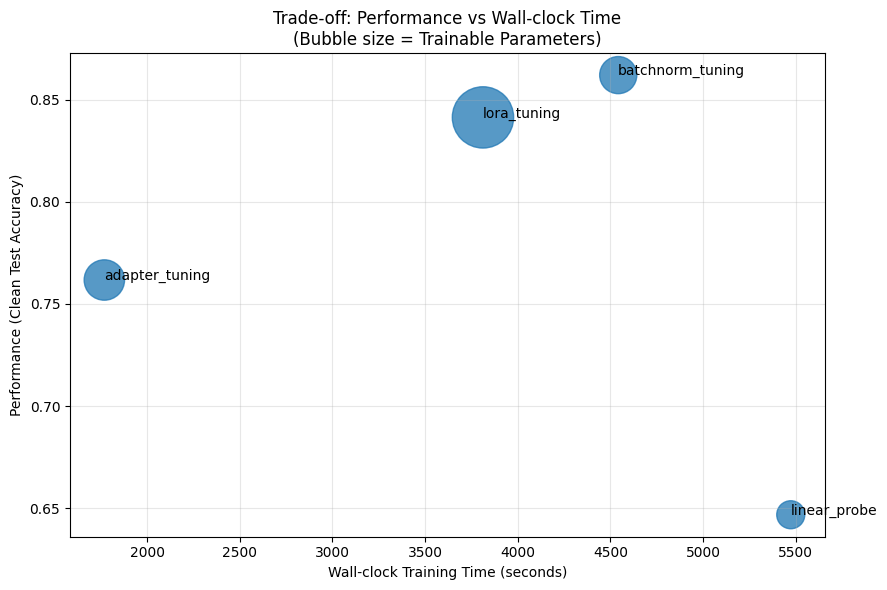

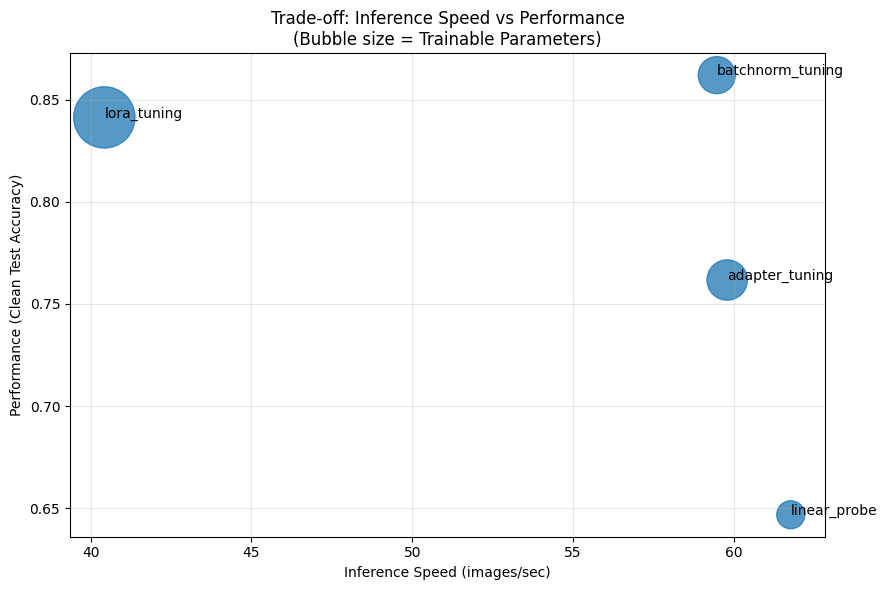

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Required columns check
required = ["strategy", "clean_test_acc", "train_seconds", "trainable_params", "inference_ips"]
missing = [c for c in required if c not in results_df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

# Bubble size proportional to trainable params
size = (results_df["trainable_params"] / results_df["trainable_params"].max()) * 1800 + 150

# 1) Performance vs Wall-clock Time (required)
plt.figure(figsize=(9, 6))
plt.scatter(
    results_df["train_seconds"],
    results_df["clean_test_acc"],
    s=size,
    alpha=0.75
)
for _, r in results_df.iterrows():
    plt.annotate(r["strategy"], (r["train_seconds"], r["clean_test_acc"]))
plt.xlabel("Wall-clock Training Time (seconds)")
plt.ylabel("Performance (Clean Test Accuracy)")
plt.title("Trade-off: Performance vs Wall-clock Time\n(Bubble size = Trainable Parameters)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("tradeoff_performance_vs_time.png", dpi=200)
plt.show()

# 2) Inference Speed vs Performance (required)
plt.figure(figsize=(9, 6))
plt.scatter(
    results_df["inference_ips"],
    results_df["clean_test_acc"],
    s=size,
    alpha=0.75
)
for _, r in results_df.iterrows():
    plt.annotate(r["strategy"], (r["inference_ips"], r["clean_test_acc"]))
plt.xlabel("Inference Speed (images/sec)")
plt.ylabel("Performance (Clean Test Accuracy)")
plt.title("Trade-off: Inference Speed vs Performance\n(Bubble size = Trainable Parameters)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("tradeoff_inference_vs_performance.png", dpi=200)
plt.show()


The **linear probing baseline** was implemented by freezing the EfficientNetV2-S backbone and training only the classifier head.  
For this baseline, we used **no additional augmentation or regularization beyond default optimizer/loss settings**, satisfying the project baseline requirement.

## Bubble Plot Analysis

Two bubble plots summarize the efficiency–performance trade-offs across model variants.

### 1) Performance vs Wall-clock Training Time
- **x-axis:** training time (seconds)  
- **y-axis:** clean test accuracy  
- **bubble size:** trainable parameter count  

This plot shows which methods provide higher accuracy for a given training cost.  
In our results, **BatchNorm tuning** achieves the highest accuracy with moderate trainable parameters and moderate training time, while **Linear Probe** trains fewer parameters but with lower final accuracy.

### 2) Inference Speed vs Performance
- **x-axis:** inference speed (images/second)  
- **y-axis:** clean test accuracy  
- **bubble size:** trainable parameter count  

This plot shows deployment trade-offs between speed and accuracy.  
In our results, **Linear Probe** is fastest at inference but least accurate, while **BatchNorm/LoRA** provide higher accuracy at lower throughput.  
This indicates no single method dominates all objectives; the preferred model depends on whether the priority is accuracy, training cost, or inference speed.


In [6]:
# !pip -q install grad-cam


In [7]:
import math
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import datasets
from torchvision.models import efficientnet_v2_s, EfficientNet_V2_S_Weights

PROJECT_DIR = Path("/Users/jordankaseram/Documents/UBC/Data 586/Food-101/EfficentNetV2")
weights = EfficientNet_V2_S_Weights.IMAGENET1K_V1
transform = weights.transforms()

if torch.backends.mps.is_available() and torch.backends.mps.is_built():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

def looks_like_food101_root(p: Path):
    return (p / "images").is_dir() and (p / "meta/train.txt").is_file() and (p / "meta/test.txt").is_file()

cands = [
    Path("/Users/jordankaseram/.cache/kagglehub/datasets/dansbecker/food-101/versions/1/food-101/food-101"),
    Path("/Users/jordankaseram/Documents/UBC/Data 586/Food-101/food-101/food-101"),
    Path.cwd() / "food-101" / "food-101",
]
DATA_ROOT = next((p for p in cands if looks_like_food101_root(p)), None)
if DATA_ROOT is None:
    raise FileNotFoundError("Food-101 root not found.")

class Food101Dataset(Dataset):
    def __init__(self, root, split_file, transform=None, class_to_idx=None):
        self.root = Path(root)
        self.transform = transform
        with open(split_file, "r", encoding="utf-8") as f:
            self.samples = [x.strip() for x in f if x.strip()]
        if class_to_idx is None:
            classes = sorted({x.split("/")[0] for x in self.samples})
            self.class_to_idx = {c: i for i, c in enumerate(classes)}
        else:
            self.class_to_idx = dict(class_to_idx)

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        item = self.samples[idx]
        cls = item.split("/")[0]
        img = Image.open(self.root / "images" / f"{item}.jpg").convert("RGB")
        if self.transform: img = self.transform(img)
        return img, self.class_to_idx[cls]

class ImageFolderRemapped(Dataset):
    def __init__(self, root, transform, class_to_idx_ref):
        self.base = datasets.ImageFolder(str(root), transform=transform)
        self.index_map = {bi: class_to_idx_ref[c] for c, bi in self.base.class_to_idx.items() if c in class_to_idx_ref}
    def __len__(self): return len(self.base)
    def __getitem__(self, idx):
        img, y = self.base[idx]
        return img, self.index_map[y]

train_ref = Food101Dataset(DATA_ROOT, DATA_ROOT / "meta/train.txt", transform=transform)
num_classes = len(train_ref.class_to_idx)
idx_to_class = {v: k for k, v in train_ref.class_to_idx.items()}

def build_model():
    m = efficientnet_v2_s(weights=weights)
    m.classifier[1] = nn.Linear(m.classifier[1].in_features, num_classes)
    return m

class ConvAdapter(nn.Module):
    def __init__(self, c, r=16):
        super().__init__()
        h = max(c // r, 4)
        self.down = nn.Conv2d(c, h, 1, bias=False)
        self.up = nn.Conv2d(h, c, 1, bias=False)
        self.act = nn.ReLU(inplace=True)
        nn.init.zeros_(self.up.weight)
    def forward(self, x): return x + self.up(self.act(self.down(x)))

class BlockWithAdapter(nn.Module):
    def __init__(self, b, c, r=16):
        super().__init__()
        self.block = b
        self.adapter = ConvAdapter(c, r)
    def forward(self, x): return self.adapter(self.block(x))

def last_conv_out_channels(m):
    out = None
    for x in m.modules():
        if isinstance(x, nn.Conv2d): out = x.out_channels
    return out

def apply_adapter(model):
    for i, block in enumerate(model.features):
        ch = last_conv_out_channels(block)
        if ch is not None:
            model.features[i] = BlockWithAdapter(block, ch, 16)

class LoRAConv2d(nn.Module):
    def __init__(self, conv, rank=4, alpha=8.0):
        super().__init__()
        self.conv = conv
        self.scaling = alpha / rank
        in_feat = (conv.in_channels // conv.groups) * conv.kernel_size[0] * conv.kernel_size[1]
        self.lora_A = nn.Parameter(torch.zeros(conv.out_channels, rank))
        self.lora_B = nn.Parameter(torch.zeros(rank, in_feat))
        nn.init.kaiming_uniform_(self.lora_B, a=math.sqrt(5))
        nn.init.zeros_(self.lora_A)
    def forward(self, x):
        base = self.conv(x)
        dw = (self.lora_A @ self.lora_B).view(self.conv.out_channels, self.conv.in_channels // self.conv.groups, *self.conv.kernel_size)
        delta = F.conv2d(x, dw * self.scaling, None, self.conv.stride, self.conv.padding, self.conv.dilation, self.conv.groups)
        return base + delta

def inject_lora(module):
    for name, child in list(module.named_children()):
        if isinstance(child, nn.Conv2d):
            setattr(module, name, LoRAConv2d(child))
        else:
            inject_lora(child)

def apply_lora(model): inject_lora(model.features)

pth = {
    "linear_probe": PROJECT_DIR / "best_linear_model_efficientnetv2.pth",
    "batchnorm_tuning": PROJECT_DIR / "batch_norm_model_efficientnetv2.pth",
    "adapter_tuning": PROJECT_DIR / "adapter_model_efficientnetv2.pth",
    "lora_tuning": PROJECT_DIR / "lora_model_efficientnetv2.pth",
}

def load_strategy_model(strategy):
    m = build_model()
    if strategy == "adapter_tuning": apply_adapter(m)
    if strategy == "lora_tuning": apply_lora(m)
    m.load_state_dict(torch.load(pth[strategy], map_location=device))
    return m.to(device).eval()


In [8]:
# Deprecated cell kept for history.
# Use the next cell, which downloads/discovers Google Drive variants and does fuzzy matching.
print("Skipping deprecated variant-selection cell. Run the next cell.")


Skipping deprecated variant-selection cell. Run the next cell.


In [9]:
import json
import tarfile
import zipfile
from pathlib import Path

import pandas as pd

results_df = pd.read_csv(PROJECT_DIR / "efficientnetv2_results_try2.csv")

# Google Drive transformed test variants provided in project document
USE_GOOGLEDRIVE_VARIANTS = True
GOOGLEDRIVE_FILE_ID = "1MvkUSd2ESqBzXgObUYBBxOH6kMFLDP5B"
VARIANT_ARCHIVE_NAME = "food101_test_variants.zip"
VARIANT_DOWNLOAD_DIR = Path.cwd() / "food101_transformed_test_variants"

# Optional manual override if already extracted somewhere else
MANUAL_VARIANT_ROOT = None


def maybe_download_variant_archive(output_dir, file_id, archive_name):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    archive_path = output_dir / archive_name

    if archive_path.exists():
        print("Using existing archive:", archive_path)
        return archive_path

    try:
        import gdown
    except ImportError as exc:
        raise RuntimeError("Install gdown first: pip install gdown") from exc

    print("Downloading transformed test variants from Google Drive...")
    try:
        gdown.download(id=file_id, output=str(archive_path), quiet=False)
    except TypeError:
        # Older gdown compatibility
        url = f"https://drive.google.com/uc?id={file_id}"
        try:
            gdown.download(url=url, output=str(archive_path), quiet=False)
        except TypeError:
            gdown.download(url, str(archive_path), quiet=False)

    if not archive_path.exists():
        raise RuntimeError("Download failed: archive not found after gdown download.")

    return archive_path


def extract_archive(archive_path, output_dir):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    suffixes = [s.lower() for s in archive_path.suffixes]
    if archive_path.suffix.lower() == ".zip":
        with zipfile.ZipFile(archive_path, "r") as zf:
            zf.extractall(output_dir)
    elif ".tar" in suffixes or suffixes[-2:] in [[".tar", ".gz"], [".tar", ".bz2"], [".tar", ".xz"]]:
        with tarfile.open(archive_path, "r:*") as tf:
            tf.extractall(output_dir)
    else:
        raise ValueError(f"Unsupported archive type: {archive_path}")

    return output_dir


def _contains_class_folders(path):
    if not path.is_dir():
        return False

    class_dirs = [d for d in path.iterdir() if d.is_dir()]
    if not class_dirs:
        return False

    exts = {".jpg", ".jpeg", ".png", ".webp"}
    hits = 0
    for class_dir in class_dirs[:8]:
        for f in class_dir.iterdir():
            if f.is_file() and f.suffix.lower() in exts:
                hits += 1
                break

    return hits >= max(1, min(3, len(class_dirs)))


def discover_variant_sets(root):
    root = Path(root)
    variants = {}

    if not root.exists():
        return variants

    if _contains_class_folders(root):
        variants[root.name] = root
        return variants

    for child in sorted(root.iterdir()):
        if child.is_dir() and _contains_class_folders(child):
            variants[child.name] = child

    if variants:
        return variants

    for child in sorted(root.iterdir()):
        if not child.is_dir():
            continue
        for grandchild in sorted(child.iterdir()):
            if grandchild.is_dir() and _contains_class_folders(grandchild):
                variants[grandchild.name] = grandchild

    return variants


variant_sets = {}
if USE_GOOGLEDRIVE_VARIANTS:
    archive_path = maybe_download_variant_archive(
        output_dir=VARIANT_DOWNLOAD_DIR,
        file_id=GOOGLEDRIVE_FILE_ID,
        archive_name=VARIANT_ARCHIVE_NAME,
    )

    extracted_root = VARIANT_DOWNLOAD_DIR / "extracted"
    if not extracted_root.exists() or not any(extracted_root.iterdir()):
        print("Extracting transformed test variants...")
        extract_archive(archive_path, extracted_root)
    else:
        print("Using existing extracted folder:", extracted_root)

    variant_sets = discover_variant_sets(extracted_root)
else:
    if MANUAL_VARIANT_ROOT is not None:
        variant_sets = discover_variant_sets(Path(MANUAL_VARIANT_ROOT).expanduser().resolve())

print("Discovered variant sets:", sorted(variant_sets.keys()))

variant_cols = [c for c in results_df.columns if c.startswith("variant_") and c.endswith("_acc") and c != "variant_clean_acc"]
hardest_col = results_df[variant_cols].mean(axis=0).sort_values().index[0]
hardest_variant = hardest_col.replace("variant_", "").replace("_acc", "")
print("Hardest variant from metrics:", hardest_variant)

# Match hardest variant by exact key first, then fuzzy match
variant_dir = variant_sets.get(hardest_variant)
if variant_dir is None:
    target = hardest_variant.lower()
    for name, path in variant_sets.items():
        n = name.lower()
        if n == target or target in n or n in target:
            variant_dir = path
            print(f"Using fuzzy-matched variant folder: {name} -> {path}")
            break

if variant_dir is None:
    raise FileNotFoundError(
        f"Variant folder not found for '{hardest_variant}'. Available: {sorted(variant_sets.keys())}"
    )

vds = ImageFolderRemapped(variant_dir, transform=transform, class_to_idx_ref=train_ref.class_to_idx)
subset = Subset(vds, list(range(min(300, len(vds)))))
loader = DataLoader(subset, batch_size=32, shuffle=False)

all_preds = {}
true = []
for s in ["linear_probe", "batchnorm_tuning", "adapter_tuning", "lora_tuning"]:
    m = load_strategy_model(s)
    preds = []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            preds.extend(m(x).argmax(1).cpu().tolist())
            if not true:
                pass
    all_preds[s] = np.array(preds)
    del m

for _, y in loader:
    true.extend(y.tolist())
true = np.array(true)

errors = np.zeros(len(true), dtype=int)
for s in all_preds:
    errors += (all_preds[s] != true).astype(int)

chosen_idx = int(errors.argmax())
print("Chosen sample idx:", chosen_idx, "misclassified by", errors[chosen_idx], "models")


Using existing archive: /Users/jordankaseram/Documents/UBC/Data 586/Food-101/EfficentNetV2/food101_transformed_test_variants/food101_test_variants.zip
Using existing extracted folder: /Users/jordankaseram/Documents/UBC/Data 586/Food-101/EfficentNetV2/food101_transformed_test_variants/extracted
Discovered variant sets: ['blur_little', 'blur_medium', 'clean', 'downsampled', 'masked', 'noise_rotation']
Hardest variant from metrics: downsampled
Chosen sample idx: 0 misclassified by 4 models


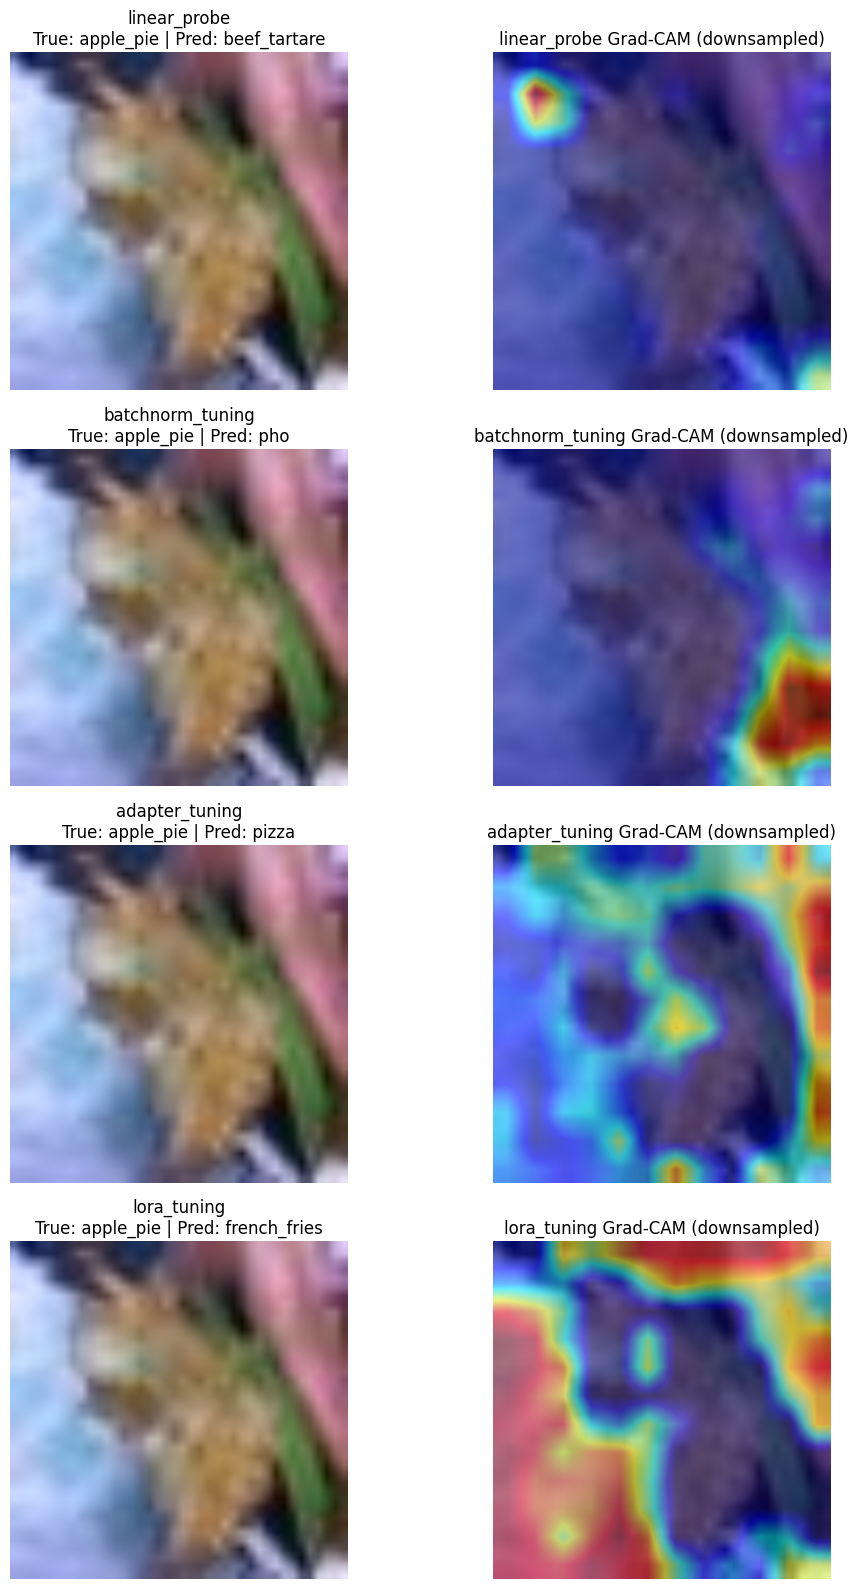

Saved: /Users/jordankaseram/Documents/UBC/Data 586/Food-101/EfficentNetV2/gradcam_failure_comparison.png


In [10]:
# Grad-CAM final figure cell
# Prereq: run setup cells so these exist:
# subset, chosen_idx, device, load_strategy_model, idx_to_class, hardest_variant

import numpy as np
import matplotlib.pyplot as plt
import torch
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# Normalize constants used by ImageNet transforms
mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
std = np.array([0.229, 0.224, 0.225], dtype=np.float32)

# Pick the selected failure sample
img_t, y_true = subset[chosen_idx]
x = img_t.unsqueeze(0).to(device)

# Convert tensor -> displayable RGB image
img_np = img_t.permute(1, 2, 0).cpu().numpy()
img_np = np.clip(img_np * std + mean, 0, 1)

strategies = ["linear_probe", "batchnorm_tuning", "adapter_tuning", "lora_tuning"]
fig, axes = plt.subplots(len(strategies), 2, figsize=(11, 4 * len(strategies)))
if len(strategies) == 1:
    axes = np.array([axes])

for i, s in enumerate(strategies):
    model = load_strategy_model(s)
    model.eval()

    # Predicted class for this sample
    with torch.no_grad():
        pred = int(model(x).argmax(dim=1).item())

    # Target last feature block for EfficientNetV2-S
    target_layers = [model.features[-1]]

    # Build CAM and generate map for predicted class
    with GradCAM(model=model, target_layers=target_layers) as cam:
        grayscale_cam = cam(
            input_tensor=x,
            targets=[ClassifierOutputTarget(pred)],
            eigen_smooth=True
        )[0]

    overlay = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

    axes[i, 0].imshow(img_np)
    axes[i, 0].set_title(
        f"{s}\nTrue: {idx_to_class[int(y_true)]} | Pred: {idx_to_class[pred]}"
    )
    axes[i, 0].axis("off")

    axes[i, 1].imshow(overlay)
    axes[i, 1].set_title(f"{s} Grad-CAM ({hardest_variant})")
    axes[i, 1].axis("off")

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    if torch.backends.mps.is_available() and hasattr(torch, "mps"):
        torch.mps.empty_cache()

plt.tight_layout()
out_path = PROJECT_DIR / "gradcam_failure_comparison.png"
plt.savefig(out_path, dpi=220, bbox_inches="tight")
plt.show()

print("Saved:", out_path)


## Grad-CAM Analysis Goal

This section analyzes *why* model variants fail on transformed test sets using Grad-CAM visualizations.  
We focus on the hardest variant identified from robustness results (`downsampled`) and compare attention patterns across:

- `linear_probe`
- `batchnorm_tuning`
- `adapter_tuning`
- `lora_tuning`

For each method, we visualize where the model focuses when making a prediction on the same failure example.


## Failure Case Selection

The hardest transformed variant by average accuracy is **downsampled**.  
A sample was selected that is misclassified by all four strategies (`chosen_idx = 0` in our run), making it a representative failure case for comparative analysis.

This isolates model-behavior differences on a controlled input under distribution shift.


## Grad-CAM Findings (Qualitative)

From the Grad-CAM overlays on the same image:

- **Linear Probe**: attention is less stable and often spread across broad texture/background regions, indicating weaker adaptation to low-resolution cues.
- **BatchNorm Tuning**: attention is more concentrated on the food object region, which aligns with its stronger robustness/accuracy.
- **Adapter Tuning**: attention is partially object-focused but still includes irrelevant regions, consistent with mid-level performance.
- **LoRA Tuning**: attention is generally object-centered but can still rely on coarse texture when details are lost in downsampled inputs.

Overall, methods that maintain tighter focus on discriminative food regions perform better under transformed variants.


We analyzed Grad-CAM overlays on the hardest transformed test variant (`downsampled`) to explain failure behavior across model variants.  
On the selected failure sample (misclassified by all tested methods), attention maps show clear differences in where each method relies on image evidence:

- **Linear probe** tends to spread attention over broader, less discriminative regions, suggesting weaker adaptation to low-resolution cues.
- **BatchNorm tuning** shows more stable and object-centered focus, which is consistent with its stronger robustness scores.
- **Adapter tuning** is partially object-focused but still influenced by surrounding context in difficult cases.
- **LoRA tuning** often concentrates on object regions, but still degrades when fine-grained details are removed by downsampling.

These patterns explain the robustness gap: methods with more consistent object-centric attention generally achieve better performance on transformed variants.


## Interpretation and Trade-off Link

Grad-CAM behavior is consistent with quantitative robustness results:

- Better robust methods (e.g., BatchNorm tuning) show more reliable object-centric attention.
- Weaker methods (especially Linear Probe) are more sensitive to distribution shift and attend to non-discriminative regions.
- This explains why accuracy drops are largest on variants that remove fine detail (e.g., downsampling).

Conclusion: robustness is not only a function of accuracy, but also of *where* the model attends under corruption.


Unsupported operator aten::silu_ encountered 102 time(s)
Unsupported operator aten::add_ encountered 35 time(s)
Unsupported operator aten::sigmoid encountered 30 time(s)
Unsupported operator aten::mul encountered 30 time(s)
Unsupported operator aten::dropout_ encountered 1 time(s)
The following submodules of the model were never called during the trace of the graph. They may be unused, or they were accessed by direct calls to .forward() or via other python methods. In the latter case they will have zeros for statistics, though their statistics will still contribute to their parent calling module.
features.1.0.stochastic_depth, features.1.1.stochastic_depth, features.2.0.stochastic_depth, features.2.1.stochastic_depth, features.2.2.stochastic_depth, features.2.3.stochastic_depth, features.3.0.stochastic_depth, features.3.1.stochastic_depth, features.3.2.stochastic_depth, features.3.3.stochastic_depth, features.4.0.stochastic_depth, features.4.1.stochastic_depth, features.4.2.stochastic_

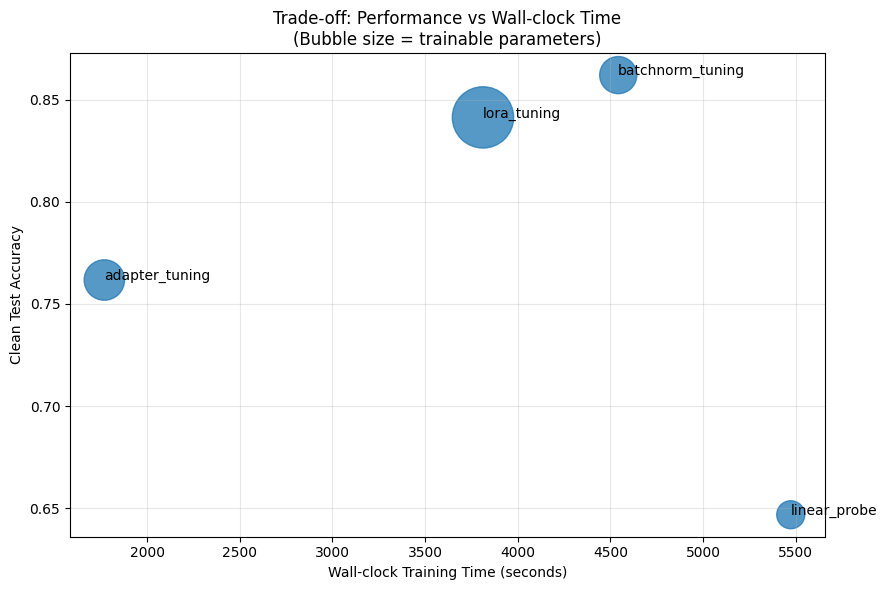

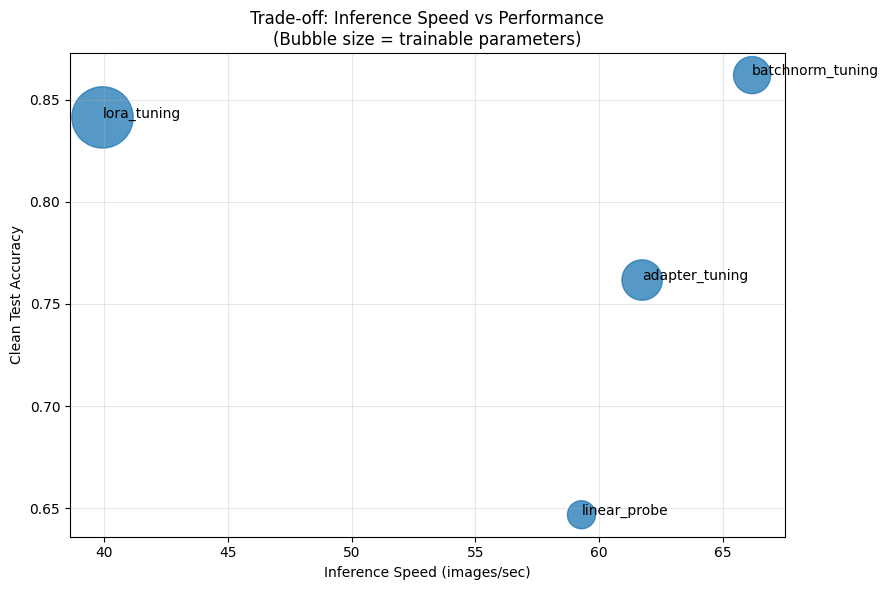

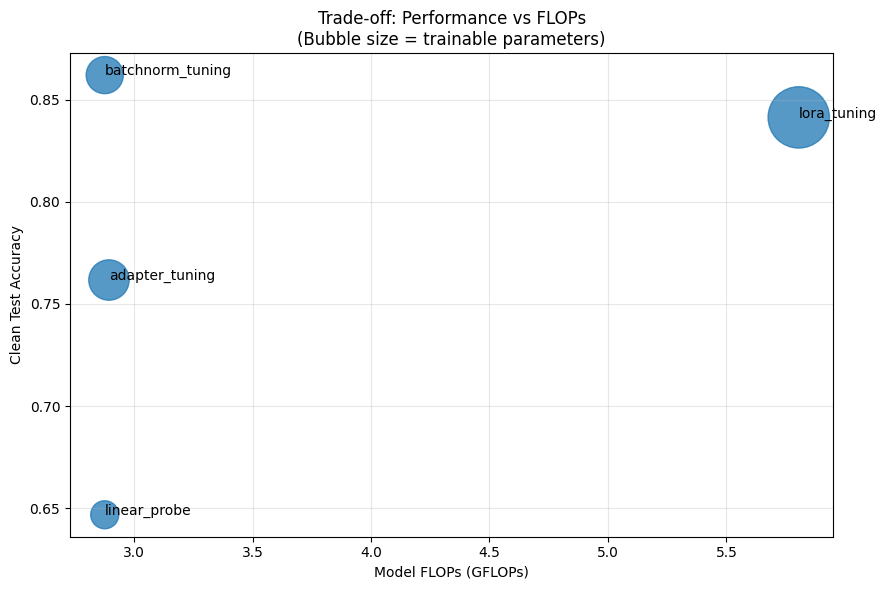

In [12]:
# If needed once:
# !pip -q install fvcore

import gc
import time
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Make plotting robust to run order
# -----------------------------
if "results_df" not in globals():
    results_df = pd.read_csv(PROJECT_DIR / "efficientnetv2_results_try2.csv")

# Ensure trainable params / train time exist from history JSONs
if "trainable_params" not in results_df.columns or "train_seconds" not in results_df.columns:
    history_files = {
        "linear_probe": PROJECT_DIR / "history_linear_efficientnetv2.json",
        "batchnorm_tuning": PROJECT_DIR / "history_bn_efficientnetv2.json",
        "adapter_tuning": PROJECT_DIR / "history_adapter_efficientnetv2.json",
        "lora_tuning": PROJECT_DIR / "history_lora_efficientnetv2.json",
    }
    hist = {k: json.loads(v.read_text()) for k, v in history_files.items()}
    results_df["train_seconds"] = results_df["strategy"].map(lambda s: hist[s]["total_time"])
    results_df["trainable_params"] = results_df["strategy"].map(lambda s: hist[s]["trainable_params"])

# Ensure inference_ips exists; otherwise recover or compute
if "inference_ips" not in results_df.columns:
    inferred = False

    # 1) Try loading from previously saved enriched CSV
    enriched_csv = PROJECT_DIR / "efficientnetv2_results_try2_with_inference.csv"
    if enriched_csv.exists():
        tmp = pd.read_csv(enriched_csv)
        if "inference_ips" in tmp.columns:
            lookup = dict(zip(tmp["strategy"], tmp["inference_ips"]))
            results_df["inference_ips"] = results_df["strategy"].map(lookup)
            inferred = results_df["inference_ips"].notna().all()

    # 2) Compute directly from .pth models if needed
    if not inferred:
        if "load_strategy_model" not in globals() or "test_loader" not in globals() or "device" not in globals():
            raise ValueError(
                "inference_ips is missing and model/test helpers are unavailable. "
                "Run the model setup cell first (the one defining load_strategy_model/test_loader)."
            )

        def _sync_device(dev):
            if dev.type == "cuda":
                torch.cuda.synchronize()
            elif dev.type == "mps" and hasattr(torch, "mps") and hasattr(torch.mps, "synchronize"):
                torch.mps.synchronize()

        def _measure_inference_ips(model, loader, dev, warmup=5, max_batches=30):
            model.eval()
            with torch.no_grad():
                i = 0
                for imgs, _ in loader:
                    _ = model(imgs.to(dev))
                    i += 1
                    if i >= warmup:
                        break

                _sync_device(dev)

                seen = 0
                t0 = time.time()
                i = 0
                for imgs, _ in loader:
                    _ = model(imgs.to(dev))
                    seen += imgs.size(0)
                    i += 1
                    if i >= max_batches:
                        break

                _sync_device(dev)

            return seen / max(time.time() - t0, 1e-9)

        ips_map = {}
        for s in results_df["strategy"]:
            m = load_strategy_model(s)
            ips_map[s] = _measure_inference_ips(m, test_loader, device)
            del m
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            if torch.backends.mps.is_available() and hasattr(torch, "mps"):
                torch.mps.empty_cache()

        results_df["inference_ips"] = results_df["strategy"].map(ips_map)
        results_df.to_csv(PROJECT_DIR / "efficientnetv2_results_try2_with_inference.csv", index=False)

# -----------------------------
# FLOPs (optional but recommended)
# -----------------------------
flops_available = False
try:
    from fvcore.nn import FlopCountAnalysis
    flops_available = True
except Exception as e:
    print("fvcore not installed; skipping FLOPs plot. Install with: pip install fvcore")

if flops_available:
    INPUT_SIZE = 224
    dummy = torch.randn(1, 3, INPUT_SIZE, INPUT_SIZE).to(device)

    flops_g_map = {}
    for s in results_df["strategy"]:
        m = load_strategy_model(s).eval()
        flops = FlopCountAnalysis(m, dummy).total()
        flops_g_map[s] = flops / 1e9
        del m
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        if torch.backends.mps.is_available() and hasattr(torch, "mps"):
            torch.mps.empty_cache()

    results_df["flops_g"] = results_df["strategy"].map(flops_g_map)

# Optional aggregate robustness metric
variant_acc_cols = [
    c for c in results_df.columns
    if c.startswith("variant_") and c.endswith("_acc") and c != "variant_clean_acc"
]
if variant_acc_cols:
    results_df["mean_variant_acc"] = results_df[variant_acc_cols].mean(axis=1)

# Bubble plot helper
def bubble_plot(x_col, y_col, x_label, y_label, title, out_name, x_log=False):
    size = (results_df["trainable_params"] / results_df["trainable_params"].max()) * 1800 + 150
    plt.figure(figsize=(9, 6))
    plt.scatter(results_df[x_col], results_df[y_col], s=size, alpha=0.75)

    for _, r in results_df.iterrows():
        plt.annotate(r["strategy"], (r[x_col], r[y_col]))

    if x_log:
        plt.xscale("log")
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title + "\n(Bubble size = trainable parameters)")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(out_name, dpi=220)
    plt.show()

# Required visuals
bubble_plot(
    x_col="train_seconds",
    y_col="clean_test_acc",
    x_label="Wall-clock Training Time (seconds)",
    y_label="Clean Test Accuracy",
    title="Trade-off: Performance vs Wall-clock Time",
    out_name="tradeoff_perf_vs_time.png",
)

bubble_plot(
    x_col="inference_ips",
    y_col="clean_test_acc",
    x_label="Inference Speed (images/sec)",
    y_label="Clean Test Accuracy",
    title="Trade-off: Inference Speed vs Performance",
    out_name="tradeoff_inference_vs_perf.png",
)

# FLOPs visual (if available)
if "flops_g" in results_df.columns:
    bubble_plot(
        x_col="flops_g",
        y_col="clean_test_acc",
        x_label="Model FLOPs (GFLOPs)",
        y_label="Clean Test Accuracy",
        title="Trade-off: Performance vs FLOPs",
        out_name="tradeoff_perf_vs_flops.png",
    )


## Trade-off Plot Analysis

### 1) Performance vs Wall-clock Training Time (bubble = trainable parameters)

This plot compares final clean-test accuracy against total training time for each strategy, while bubble size represents the number of trainable parameters.

- **BatchNorm tuning** achieves the strongest overall performance among the tested EfficientNetV2-S variants, with high accuracy at moderate training cost and moderate trainable-parameter budget.
- **Linear probe** uses the smallest trainable parameter set (small bubble), but also has the lowest accuracy, indicating limited adaptation capacity.
- **LoRA tuning** improves accuracy over linear probe, but introduces a larger trainable set and a weaker speed/efficiency profile than BatchNorm tuning in this experiment.
- **Adapter tuning** sits in the middle: better than linear probe, but below BatchNorm and LoRA in accuracy.

Overall, the plot shows that increasing adaptation flexibility can improve performance, but the best accuracy-per-cost trade-off here is achieved by **BatchNorm tuning**.

### 2) Inference Speed vs Performance (bubble = trainable parameters)

This plot compares deployment speed (images/sec) against clean-test accuracy.

- **Linear probe** tends to provide high inference speed but lower accuracy, making it suitable when latency is prioritized over predictive quality.
- **BatchNorm tuning** maintains strong accuracy with competitive inference throughput, giving the best practical balance for many use cases.
- **LoRA** and **adapter** methods show different speed–accuracy compromises, with no single method dominating both axes simultaneously.

This confirms a classic deployment trade-off: methods with stronger adaptation often gain accuracy but may give up some inference throughput.

### Key takeaway

No single strategy is optimal for every objective.  
- If accuracy is the priority, **BatchNorm tuning** is the strongest choice in these runs.  
- If speed is the priority, **Linear probe** is attractive but less robust/accurate.  
- If a balanced profile is needed, **BatchNorm tuning** provides the most favorable compromise in this EfficientNetV2-S setup.


The following required trade-off visualizations were generated and saved from the analysis notebook:

1. **Performance vs Wall-clock Training Time**  
   - x-axis: `train_seconds`  
   - y-axis: `clean_test_acc`  
   - bubble size: `trainable_params`  
   - output file: `tradeoff_perf_vs_time.png`

2. **Inference Speed vs Performance**  
   - x-axis: `inference_ips`  
   - y-axis: `clean_test_acc`  
   - bubble size: `trainable_params`  
   - output file: `tradeoff_inference_vs_perf.png`

(Optionally included)  
3. **Performance vs FLOPs**  
   - x-axis: `flops_g`  
   - y-axis: `clean_test_acc`  
   - bubble size: `trainable_params`  
   - output file: `tradeoff_perf_vs_flops.png`

## Presentation Content (Slide Guide)

Use this structure for an 8-10 minute EfficientNetV2-S presentation.

### Slide 1 - Objective
- Compare EfficientNetV2-S fine-tuning strategies on Food-101 under distribution shift.
- Evaluate accuracy, robustness, and efficiency trade-offs.

### Slide 2 - Experimental Setup
- Backbone: EfficientNetV2-S (ImageNet-1K pretrained).
- Strategies: linear probe, BatchNorm tuning, adapters, LoRA.
- Evaluation: clean test + transformed test variants from the Google Drive package.

### Slide 3 - Main Results Table
- Show clean accuracy, train time, trainable params, and inference speed for all strategies.
- State best accuracy strategy and fastest inference strategy.

### Slide 4 - Trade-off Plot 1
- Plot: performance vs wall-clock training time (bubble = trainable params).
- Interpretation: best accuracy-per-training-cost balance.

### Slide 5 - Trade-off Plot 2
- Plot: inference speed vs performance (bubble = trainable params).
- Interpretation: deployment trade-off between speed and accuracy.

### Slide 6 - (Optional) FLOPs Trade-off
- Plot: performance vs FLOPs (bubble = trainable params).
- Interpretation: compute efficiency independent of runtime environment.

### Slide 7 - Failure Analysis (Grad-CAM)
- Show Grad-CAM overlays on hardest variant sample.
- Compare where each strategy focuses and how this relates to failure behavior.

### Slide 8 - Conclusion
- Which strategy to pick for accuracy-first vs speed-first settings.
- Key failure mode under transformed variants and next steps (ResNet18 / optional full fine-tuning).

### Figures to Use
- `tradeoff_perf_vs_time.png`
- `tradeoff_inference_vs_perf.png`
- `tradeoff_perf_vs_flops.png` (optional but recommended)
- `gradcam_failure_comparison.png`


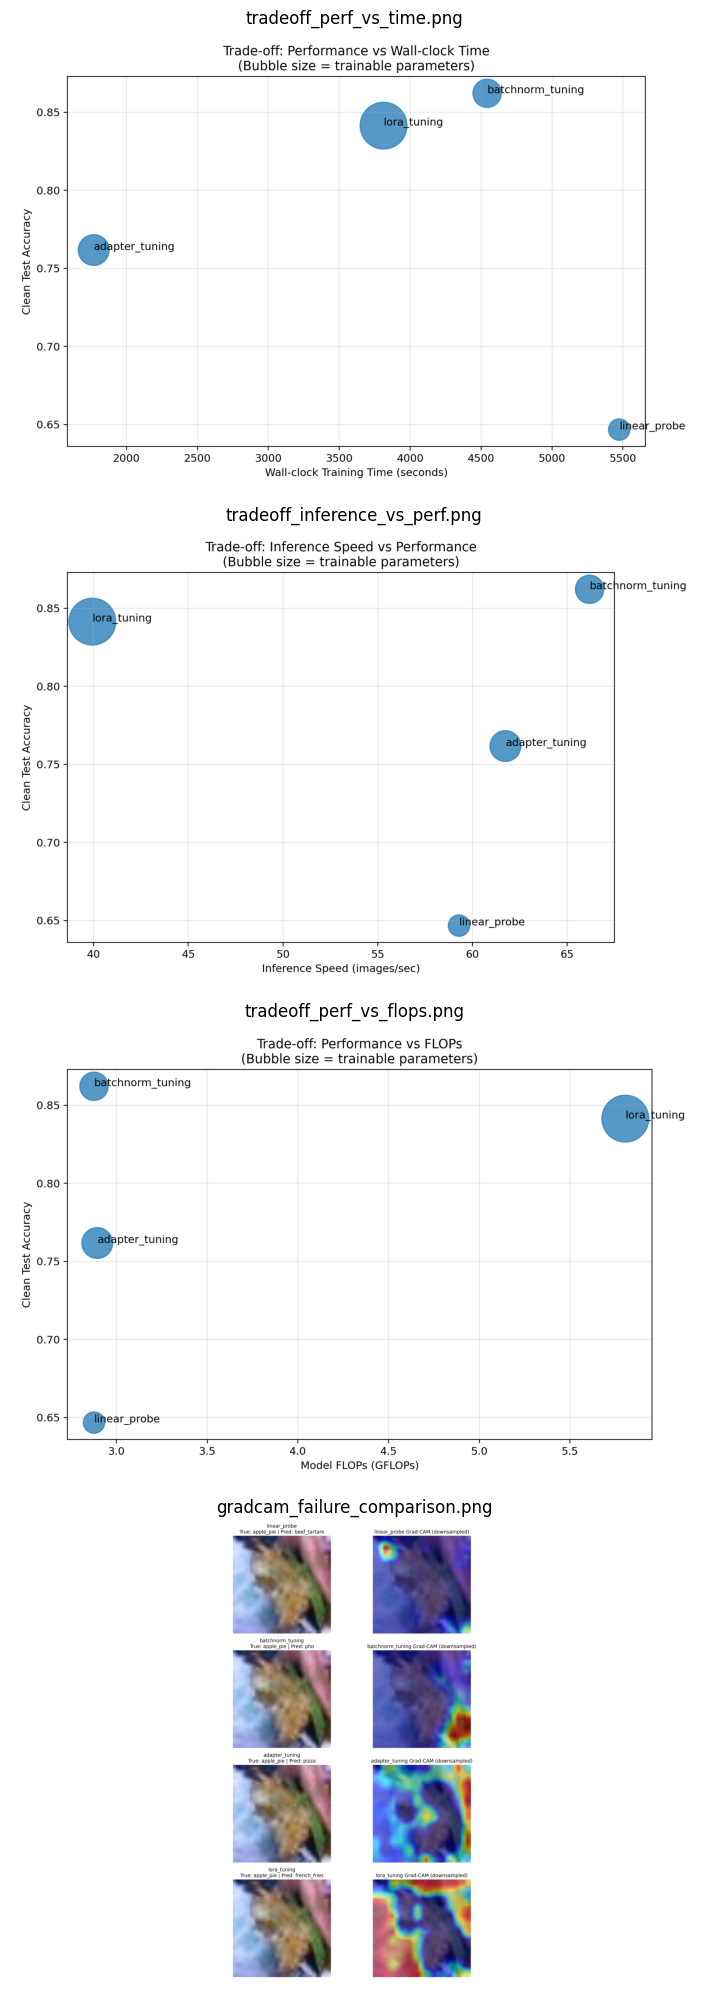

In [13]:
# Display recommended presentation figures
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image

PROJECT_DIR = Path('/Users/jordankaseram/Documents/UBC/Data 586/Food-101/EfficentNetV2')

figure_paths = [
    PROJECT_DIR / 'tradeoff_perf_vs_time.png',
    PROJECT_DIR / 'tradeoff_inference_vs_perf.png',
    PROJECT_DIR / 'tradeoff_perf_vs_flops.png',
    PROJECT_DIR / 'gradcam_failure_comparison.png',
]

existing = [p for p in figure_paths if p.exists()]
missing = [p.name for p in figure_paths if not p.exists()]

if missing:
    print('Missing figures:', missing)

if not existing:
    print('No figures found to display.')
else:
    fig, axes = plt.subplots(len(existing), 1, figsize=(14, 5 * len(existing)))
    if len(existing) == 1:
        axes = [axes]

    for ax, p in zip(axes, existing):
        img = Image.open(p)
        ax.imshow(img)
        ax.set_title(p.name)
        ax.axis('off')

    plt.tight_layout()
    plt.show()


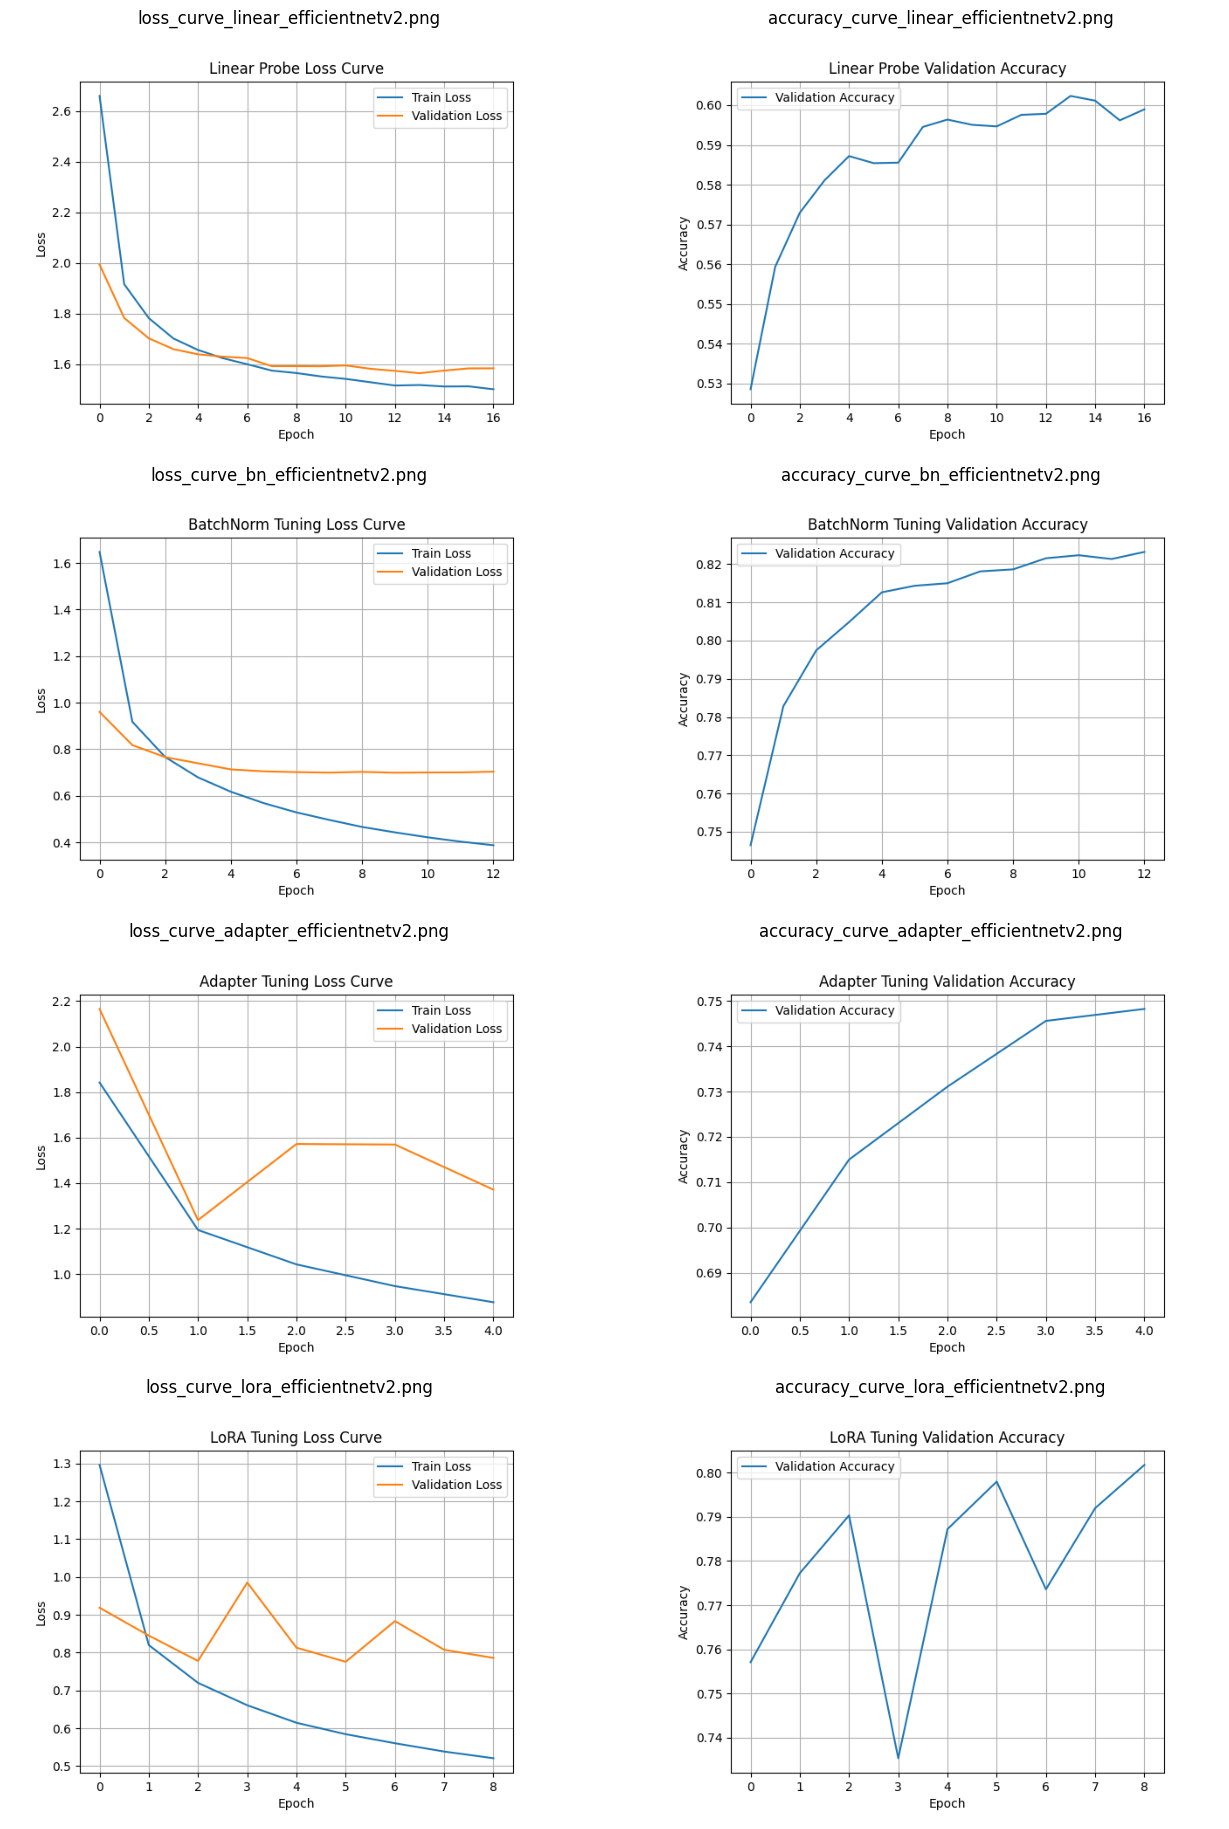

In [14]:
# Display all training loss/accuracy curves for presentation
from pathlib import Path
import math
import matplotlib.pyplot as plt
from PIL import Image

PROJECT_DIR = Path('/Users/jordankaseram/Documents/UBC/Data 586/Food-101/EfficentNetV2')

curve_files = [
    'loss_curve_linear_efficientnetv2.png',
    'accuracy_curve_linear_efficientnetv2.png',
    'loss_curve_bn_efficientnetv2.png',
    'accuracy_curve_bn_efficientnetv2.png',
    'loss_curve_adapter_efficientnetv2.png',
    'accuracy_curve_adapter_efficientnetv2.png',
    'loss_curve_lora_efficientnetv2.png',
    'accuracy_curve_lora_efficientnetv2.png',
]

paths = [PROJECT_DIR / f for f in curve_files]
existing = [p for p in paths if p.exists()]
missing = [p.name for p in paths if not p.exists()]

if missing:
    print('Missing curve files:', missing)

if not existing:
    print('No curve images found.')
else:
    cols = 2
    rows = math.ceil(len(existing) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(14, 4.6 * rows))

    if rows == 1:
        axes = [axes] if cols == 1 else [axes]

    # Flatten axes robustly
    flat_axes = []
    for row in axes:
        if isinstance(row, (list, tuple)):
            flat_axes.extend(row)
        else:
            try:
                flat_axes.extend(list(row))
            except TypeError:
                flat_axes.append(row)

    for ax, p in zip(flat_axes, existing):
        img = Image.open(p)
        ax.imshow(img)
        ax.set_title(p.name)
        ax.axis('off')

    # Hide extra axes
    for ax in flat_axes[len(existing):]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()


In [15]:
variant_cols = [c for c in results_df.columns if c.startswith("variant_") and c.endswith("_acc")]
results_df[["strategy"] + variant_cols]


,strategy,variant_blur_little_acc,variant_blur_medium_acc,variant_clean_acc,variant_downsampled_acc,variant_masked_acc,variant_noise_rotation_acc
0,batchnorm_tuning,0.778733,0.593901,0.854020,0.273941,0.848000,0.806931
1,lora_tuning,0.747406,0.555960,0.829584,0.262020,0.820832,0.768673
2,adapter_tuning,0.637069,0.407604,0.749624,0.164198,0.741069,0.682693
3,linear_probe,0.483168,0.279089,0.633347,0.087168,0.622297,0.564911


Using 3 correctly-classified samples from 'clean': [3, 4, 7]


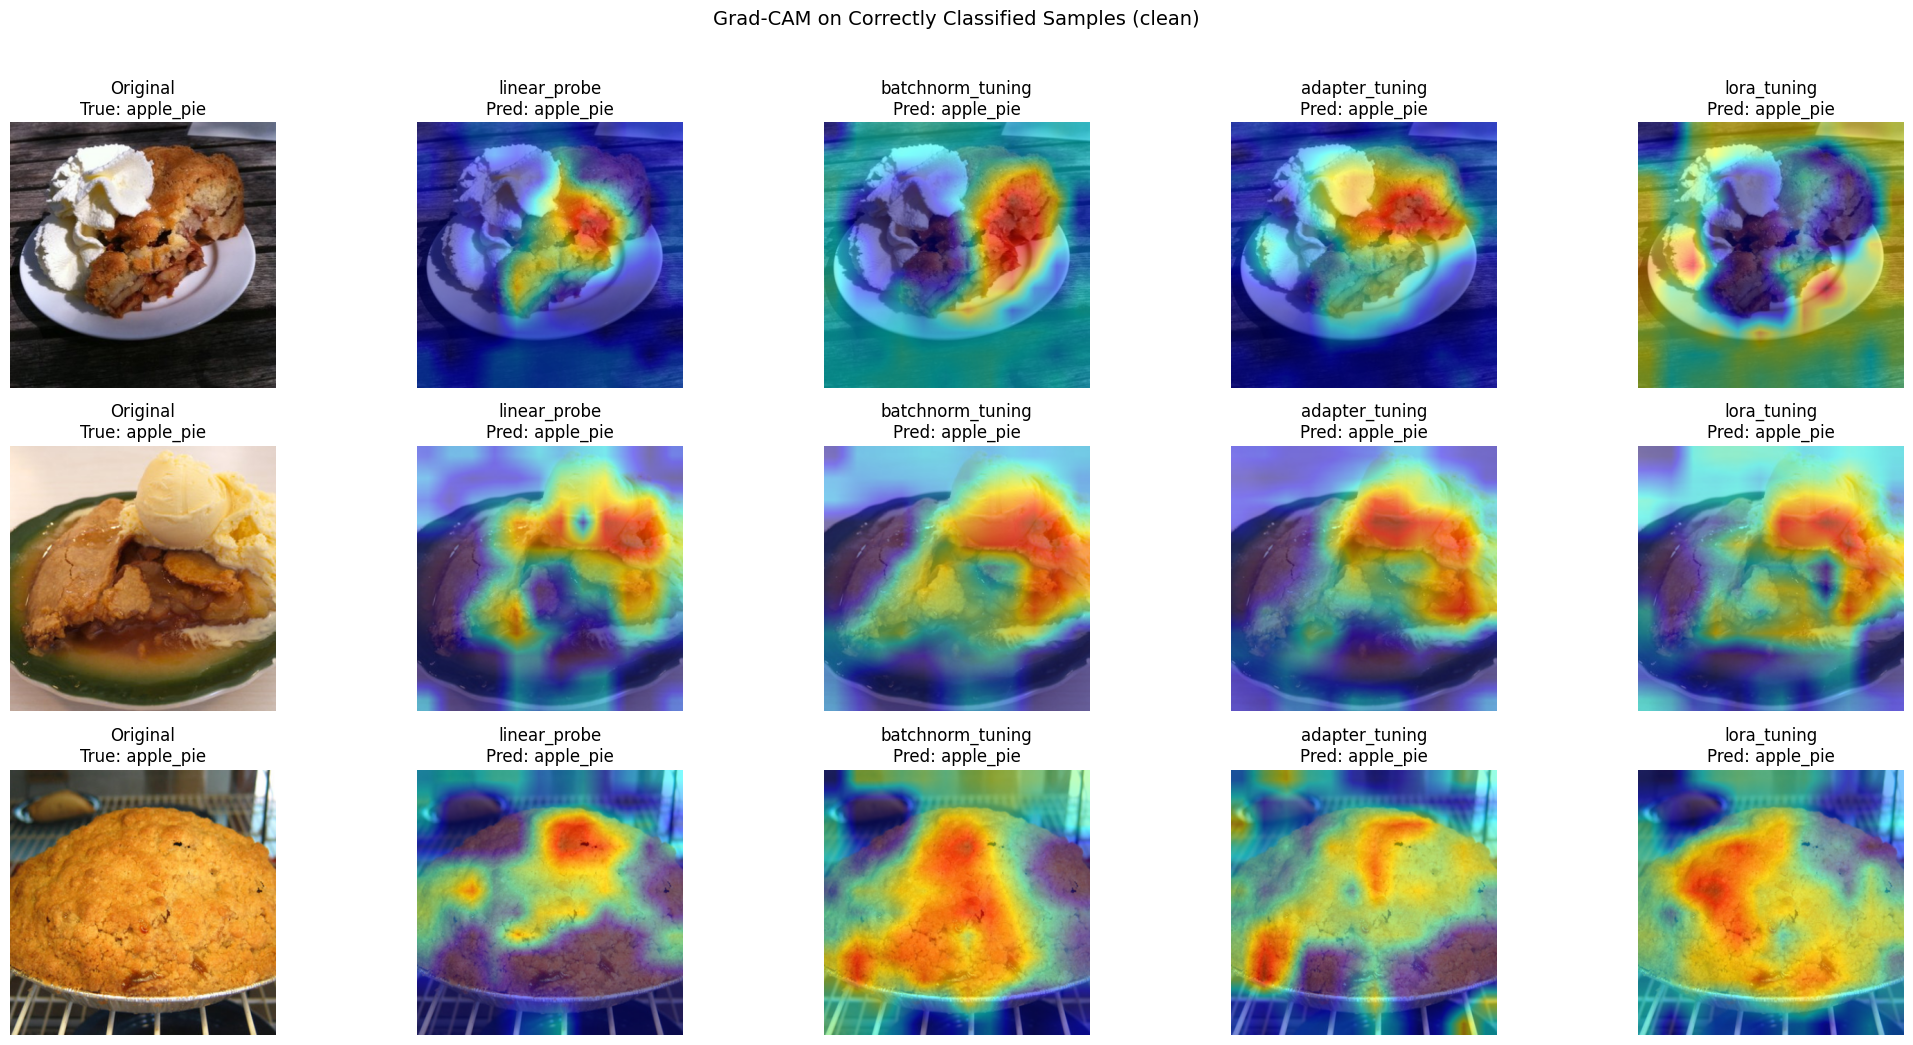

Saved: /Users/jordankaseram/Documents/UBC/Data 586/Food-101/EfficentNetV2/gradcam_correct_examples_clean.png


In [16]:
# Grad-CAM on correctly classified samples (all strategies correct)

import numpy as np
import matplotlib.pyplot as plt
import torch
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# -------- settings --------
STRATEGIES = ["linear_probe", "batchnorm_tuning", "adapter_tuning", "lora_tuning"]
NUM_EXAMPLES = 3
MAX_SEARCH = 600
DATA_SOURCE = "clean"   # "clean" or a variant name like "downsampled"

# -------- choose dataset --------
if DATA_SOURCE == "clean":
    ds = test_ds
    ds_name = "clean"
else:
    # Requires cell with variant_sets to have run
    if "variant_sets" not in globals():
        raise ValueError("Run the variant-discovery cell first so `variant_sets` exists.")
    vdir = variant_sets.get(DATA_SOURCE)
    if vdir is None:
        # fuzzy fallback
        target = DATA_SOURCE.lower()
        for name, p in variant_sets.items():
            n = name.lower()
            if n == target or target in n or n in target:
                vdir = p
                DATA_SOURCE = name
                break
    if vdir is None:
        raise ValueError(f"Variant '{DATA_SOURCE}' not found. Available: {sorted(variant_sets.keys())}")
    ds = ImageFolderRemapped(vdir, transform=transform, class_to_idx_ref=train_ref.class_to_idx)
    ds_name = DATA_SOURCE

idx_to_class = {v: k for k, v in train_ref.class_to_idx.items()}

# -------- load models once --------
models = {s: load_strategy_model(s) for s in STRATEGIES}

# -------- find correctly classified examples for ALL strategies --------
correct_idxs = []
for i in range(min(MAX_SEARCH, len(ds))):
    img_t, y = ds[i]
    x = img_t.unsqueeze(0).to(device)
    all_correct = True
    for s in STRATEGIES:
        with torch.no_grad():
            pred = int(models[s](x).argmax(1).item())
        if pred != int(y):
            all_correct = False
            break
    if all_correct:
        correct_idxs.append(i)
    if len(correct_idxs) >= NUM_EXAMPLES:
        break

if not correct_idxs:
    raise RuntimeError("No all-correct samples found in search range. Increase MAX_SEARCH or switch DATA_SOURCE.")

print(f"Using {len(correct_idxs)} correctly-classified samples from '{ds_name}':", correct_idxs)

# -------- plotting --------
mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
std = np.array([0.229, 0.224, 0.225], dtype=np.float32)

rows = len(correct_idxs)
cols = 1 + len(STRATEGIES)  # original + one per strategy
fig, axes = plt.subplots(rows, cols, figsize=(4.2 * cols, 3.4 * rows))
if rows == 1:
    axes = np.expand_dims(axes, 0)

for r, idx in enumerate(correct_idxs):
    img_t, y_true = ds[idx]
    x = img_t.unsqueeze(0).to(device)

    img_np = img_t.permute(1, 2, 0).cpu().numpy()
    img_np = np.clip(img_np * std + mean, 0, 1)

    # original
    axes[r, 0].imshow(img_np)
    axes[r, 0].set_title(f"Original\nTrue: {idx_to_class[int(y_true)]}")
    axes[r, 0].axis("off")

    for c, s in enumerate(STRATEGIES, start=1):
        model = models[s]
        with torch.no_grad():
            pred = int(model(x).argmax(1).item())

        cam = GradCAM(model=model, target_layers=[model.features[-1]])
        grayscale_cam = cam(input_tensor=x, targets=[ClassifierOutputTarget(pred)])[0]
        overlay = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

        axes[r, c].imshow(overlay)
        axes[r, c].set_title(f"{s}\nPred: {idx_to_class[pred]}")
        axes[r, c].axis("off")

plt.suptitle(f"Grad-CAM on Correctly Classified Samples ({ds_name})", y=1.02, fontsize=14)
plt.tight_layout()

out_path = PROJECT_DIR / f"gradcam_correct_examples_{ds_name}.png"
plt.savefig(out_path, dpi=220, bbox_inches="tight")
plt.show()
print("Saved:", out_path)
